In [1]:
!pip install yfinance pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]4/5 [yfinance]s]


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
tickers = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
    "XRP": "XRP-USD",
    "ADA": "ADA-USD"
}

start_date = "2023-01-01"

prices = yf.download(
    list(tickers.values()),
    start=start_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices.columns = list(tickers.keys())

prices = prices.dropna()

print("Data starts from:", prices.index.min())
print("Data ends at:", prices.index.max())

prices.tail()

Data starts from: 2023-01-01 00:00:00
Data ends at: 2026-05-16 00:00:00


,BTC,ETH,SOL,XRP,ADA
Date,,,,,
2026-05-12,0.270914,80477.492188,2274.643555,94.284294,1.436101
2026-05-13,0.264659,79277.117188,2257.576416,91.085472,1.426346
2026-05-14,0.270159,81051.250000,2280.934814,92.148727,1.484111
2026-05-15,0.261488,79065.679688,2223.328857,89.200356,1.433731
2026-05-16,0.255300,78159.000000,2172.629883,86.610001,1.416500


In [8]:
prices.tail(10)

,BTC,ETH,SOL,XRP,ADA
Date,,,,,
2026-05-07,0.262623,80009.992188,2291.107666,88.404785,1.387125
2026-05-08,0.273260,80186.765625,2306.972168,91.949821,1.418285
2026-05-09,0.270789,80664.367188,2326.727295,93.145515,1.420107
2026-05-10,0.282501,82138.929688,2369.043945,96.426987,1.472807
2026-05-11,0.280534,81728.296875,2339.360840,97.350151,1.476816
2026-05-12,0.270914,80477.492188,2274.643555,94.284294,1.436101
2026-05-13,0.264659,79277.117188,2257.576416,91.085472,1.426346
2026-05-14,0.270159,81051.250000,2280.934814,92.148727,1.484111
2026-05-15,0.261488,79065.679688,2223.328857,89.200356,1.433731


In [9]:
returns = np.log(prices / prices.shift(1)).dropna()

weights = pd.Series({
    "BTC": 0.45,
    "ETH": 0.30,
    "SOL": 0.10,
    "XRP": 0.10,
    "ADA": 0.05
})

In [10]:
basket_return = returns.mul(weights, axis=1).sum(axis=1)

rolling_window = 30

vol = pd.DataFrame({
    "BTC": returns["BTC"].rolling(rolling_window).std() * np.sqrt(365),
    "ETH": returns["ETH"].rolling(rolling_window).std() * np.sqrt(365),
    "Crypto Basket": basket_return.rolling(rolling_window).std() * np.sqrt(365)
}).dropna()

vol.tail()

,BTC,ETH,Crypto Basket
Date,,,
2026-05-12,0.472270,0.318786,0.380116
2026-05-13,0.451320,0.276678,0.343184
2026-05-14,0.433465,0.284337,0.336536
2026-05-15,0.444306,0.299520,0.350669
2026-05-16,0.413517,0.302916,0.341113


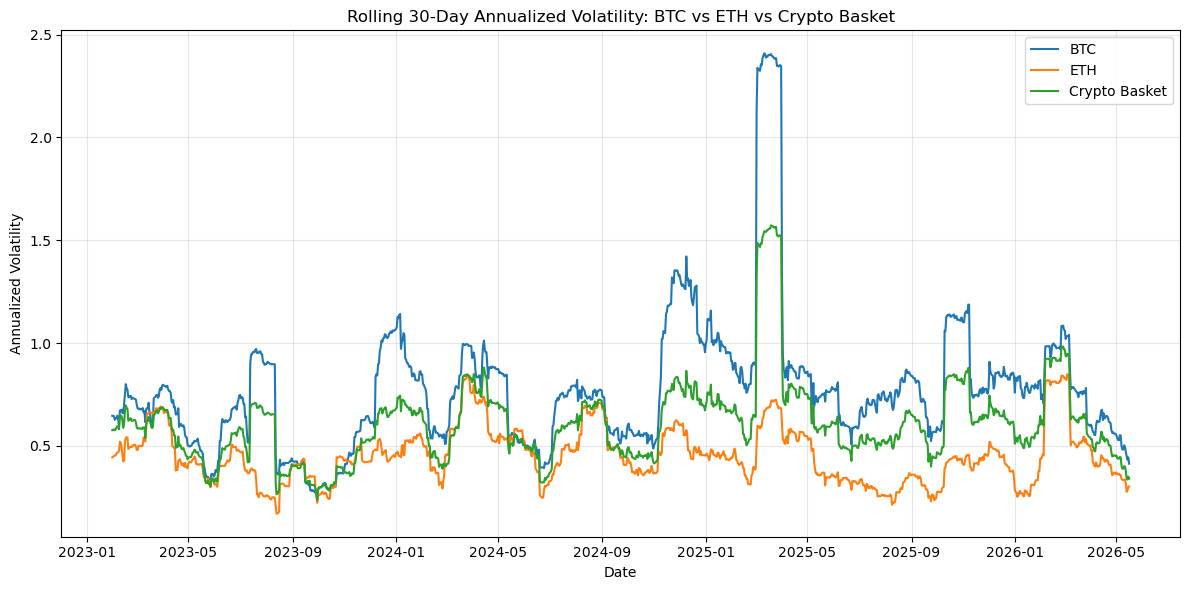

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(vol.index, vol["BTC"], label="BTC")
plt.plot(vol.index, vol["ETH"], label="ETH")
plt.plot(vol.index, vol["Crypto Basket"], label="Crypto Basket")

plt.title("Rolling 30-Day Annualized Volatility: BTC vs ETH vs Crypto Basket")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "rolling_vol_crypto_basket_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()